In [1]:
import numpy as np
import scipy.integrate

import matplotlib.pyplot as plt
import panel as pn
pn.extension()

* Should we work with non-dimensional versions of these equations?
* Do we need to do any multistability analysis? Or write the steady-state in terms of model parameters

# Parameters

In [2]:
default_param_max = 4
default_param_min = -4
default_param_step = 0.1

# Parameters
log_alpha = 0
log_beta = 0
log_gamma = 0
nH = 2

log_alpha_slider = pn.widgets.FloatSlider(
    name="$log alpha$", 
    start=default_param_min, 
    end=default_param_max, 
    step=default_param_step, 
    value=log_alpha,
    width=300
)

log_beta_slider = pn.widgets.FloatSlider(
    name="$log beta$", 
    start=default_param_min, 
    end=default_param_max, 
    step=default_param_step, 
    value=log_beta,
    width=300
)
log_gamma_slider = pn.widgets.FloatSlider(
    name="$log gamma$", 
    start=default_param_min, 
    end=default_param_max, 
    step=default_param_step, 
    value=log_gamma,
    width=300
)
nH_slider = pn.widgets.FloatSlider(
    name="$n_H$", start=0, end=10, step=0.1, value=nH,
    width=300
)

# Additional for cascade
log_kappa = 0
nI = 2

log_kappa_i_slider = pn.widgets.FloatSlider(
    name="$log kappa_i$", 
    start=default_param_min, 
    end=default_param_max, 
    step=default_param_step, 
    value=log_kappa,
    width=300
)

nI_slider = pn.widgets.FloatSlider(
    name="$n_I$", start=0, end=10, step=0.1, value=nI,
    width=300
)

# Additional for autoactivator
nF = 2

log_kappa_f_slider = pn.widgets.FloatSlider(
    name="$log kappa_f$", 
    start=default_param_min, 
    end=default_param_max, 
    step=default_param_step, 
    value=log_kappa,
    width=300
)

nF_slider = pn.widgets.FloatSlider(
    name="$n_F$", start=0, end=10, step=0.1, value=nF,
    width=300
)

# Additional for feedforward/feedback
nJ = 2

sign_select = pn.widgets.Select(
    name='Sign of regulation', 
    options=['positive', 'negative'],
    value='positive',
)

log_kappa_j_slider = pn.widgets.FloatSlider(
    name="$log kappa_j$", 
    start=default_param_min, 
    end=default_param_max, 
    step=default_param_step, 
    value=log_kappa,
    width=300
)

nJ_slider = pn.widgets.FloatSlider(
    name="$n_J$", start=0, end=10, step=0.1, value=nJ,
    width=300
)

## Colors

In [3]:
color_dict = {'U': '#fcfcfc',
             'H': '#e34986',
             'E': '#adadad',
             'I': '#2eaff0',
             'J': '#17b384',
             'F': '#3ef02e',
             }

# Simple activation circuit

In [4]:
#             E
#             |
#             V
#   U ---> H ---> F

* Species: $U, H, E, F$
* Parameters: 
    * Dilution: $c_2, h_2, b$
    * Production: $h_1$
    * Activation: $c_2?, n_H, a, K$
\begin{align}
\\ \frac{dU}{dt} &= 0
\\ \frac{dH}{dt} &= U - c_2 H
\\ \frac{dE}{dt} &= h_1 - h_2 E
\\ \frac{dF}{dt} &= aE \frac{(c_2H)^{n_H}}{K + (c_2H)^{n_H}} - b F
\end{align}

_Potentially modified to make it analytically solveable._

* Species: $U, H, E, F$
* Parameters: 
    * Dilution: $\nu, \nu_E$
    * Production: $\rho, \eta$
    * Activation: $a, n_H, K_H$
\begin{align}
\\ \frac{dU}{dt} &= 0
\\ \frac{dH}{dt} &= \eta U - \nu H
\\ \frac{dE}{dt} &= \rho - \nu_E E
\\ \frac{dF}{dt} &= aE \frac{(\frac{H}{K_H})^{n_H}}{1 + (\frac{H}{K_H})^{n_H}} - \nu F
\end{align}

_Non-dimensional_

* Parameters:
    * $\alpha = \frac{\eta}{\nu}$
    * $\beta = \frac{\rho}{K_H \nu}$
    * $\gamma = \frac{a}{\nu}$
    * $n_H$
    
\begin{align}
\\ \frac{dU}{dt} &= 0
\\ \frac{dH}{dt} &= \alpha U - H
\\ \frac{dE}{dt} &= \beta - E
\\ \frac{dF}{dt} &= \gamma E \frac{H^{n_H}}{1 + H^{n_H}} - F
\end{align}

## Time derivatives

In [5]:
def dy_dt_activation(t, y, prms):
    """
    Inputs:
    -------
    t: float
    y: array (4,)
        U, H, E, F
    prms: array (5,)
        alpha, beta, gamma, nH
        
    Outputs:
    --------
    dy_dt: array (4,)
    """
    alpha, beta, gamma, nH = prms
    U, H, E, F = y
    
    dU_dt = 0
    dH_dt = alpha*U - H
    dE_dt = beta - E
    dF_dt = gamma * E * H**nH / (1 + H**nH) - F
    
    return np.array([dU_dt, dH_dt, dE_dt, dF_dt])
    
    

## Interactive plot

In [6]:
@pn.depends(
    log_alpha_slider.param.value,
    log_beta_slider.param.value,
    log_gamma_slider.param.value,
    nH_slider.param.value,
)
def simulate_activation(log_alpha, log_beta, log_gamma, nH,
                        species_names = ['U','H','E','F']):
    
    alpha, beta, gamma = 10.**np.array([log_alpha, log_beta, log_gamma])

    prms = (alpha, beta, gamma, nH)

    fig, axes = plt.subplots(1,2, figsize=(10,3))
    t_span = (0, 20)

    # Initial conditions
    rng = np.random.default_rng(10)

    U_0 = 1
    H_0 = 0
    E_0 = rng.poisson(lam=beta)
    F_0 = 0
    y0 = np.array([U_0, H_0, E_0, F_0])

    # On dynamics
    on_res = scipy.integrate.solve_ivp(lambda t, y: dy_dt_activation(t, y, prms=prms), t_span, y0)

    for s, species in enumerate(species_names):
        axes[0].plot(on_res.t, on_res.y[s], '.-', 
                     color=color_dict[species],
                     label=species)

    axes[0].legend()
    axes[0].set_title('On Dynamics')

    # steady-state
    U_ss = 0
    H_ss = on_res.y[1,-1]
    E_ss = on_res.y[2,-1]
    F_ss = on_res.y[3,-1]
    y_ss = np.array([U_ss, H_ss, E_ss, F_ss])

    # Off dynamics
    off_res = scipy.integrate.solve_ivp(lambda t, y: dy_dt_activation(t, y, prms=prms), t_span, y_ss)

    for s, species in enumerate(species_names):
        axes[1].plot(off_res.t, off_res.y[s], '.-', 
                     color=color_dict[species],
                     label=species)

    axes[1].legend()
    axes[1].set_title('On Dynamics')
    
    plt.close(fig)
    
    return fig

Row
    [0] Column
        [0] FloatSlider(end=4, name='$log alpha$', start=-4, width=300)
        [1] FloatSlider(end=4, name='$log beta$', start=-4, width=300)
        [2] FloatSlider(end=4, name='$log gamma$', start=-4, width=300)
        [3] FloatSlider(end=10, name='$n_H$', value=2, width=300)
    [1] ParamFunction(function)
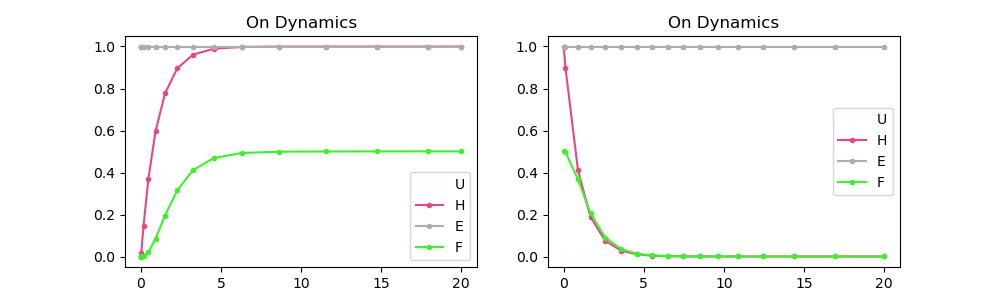

In [7]:
pn.Row(
    pn.Column(log_alpha_slider,
        log_beta_slider,
        log_gamma_slider,
        nH_slider,
        ),
    simulate_activation,
    )

# Simple cascade

In [8]:
#                 E
#             |      |
#             V      V
#   U ---> H ---> I ---> F

* Species: $U, H, E, I, F$
* Parameters: 
    * Dilution: $\nu$
    * Production: $\eta, \rho$
    * Activation: $a, n_H, K_H, n_I, K_I$
\begin{align}
\\ \frac{dU}{dt} &= 0
\\ \frac{dH}{dt} &= \eta U - \nu H
\\ \frac{dE}{dt} &= \rho - \nu E
\\ \frac{dI}{dt} &= aE \frac{H^{n_H}}{K_H^{n_H} + H^{n_H}} - \nu I
\\ \frac{dF}{dt} &= aE \frac{I^{n_I}}{K_I^{n_I} + I^{n_I}} - \nu F
\end{align}

_Non-dimensional_
* Parameters:
    * $\alpha = \frac{\eta}{\nu}$
    * $\beta = \frac{\rho}{K_H \nu}$
    * $\gamma = \frac{a}{\nu}$
    * $\kappa_I = \left(\frac{K_I}{K_H}\right)^{n_I}$
    * $n_H, n_I$
    
\begin{align}
\\ \frac{dU}{dt} &= 0
\\ \frac{dH}{dt} &= \alpha U - H
\\ \frac{dE}{dt} &= \beta - E
\\ \frac{dI}{dt} &= \gamma E \frac{H^{n_H}}{1 + H^{n_H}} - I
\\ \frac{dF}{dt} &= \gamma E \frac{I^{n_I}}{ \kappa_I + I^{n_I}} - F
\end{align}

## Time derivatives

In [9]:
def dy_dt_cascade(t, y, prms):
    """
    Inputs:
    -------
    t: float
    y: array (5,)
        U, H, E, I, F
    prms: array (6,)
        alpha, beta, gamma, kappa_i, nH, nI
        
    Outputs:
    --------
    dy_dt: array (5,)
    """
    alpha, beta, gamma, kappa_i, nH, nI = prms
    U, H, E, I, F = y
    
    dU_dt = 0
    dH_dt = alpha*U - H
    dE_dt = beta - E
    dI_dt = gamma * E * H**nH / (1 + H**nH) - I
    dF_dt = gamma * E * I**nI / (kappa_i + I**nI) - F
    
    return np.array([dU_dt, dH_dt, dE_dt, dI_dt, dF_dt])
    
    

## Interactive plot

In [10]:
@pn.depends(
    log_alpha_slider.param.value,
    log_beta_slider.param.value,
    log_gamma_slider.param.value,
    log_kappa_i_slider.param.value,
    nH_slider.param.value,
    nI_slider.param.value,
)
def simulate_cascade(log_alpha, log_beta, log_gamma, log_kappa_i, nH, nI,
                        species_names = ['U','H','E','I','F']):

    alpha, beta, gamma, kappa_i = 10.**np.array([log_alpha, log_beta, log_gamma, log_kappa_i])

    prms = (alpha, beta, gamma, kappa_i, nH, nI)
    
    fig, axes = plt.subplots(1,2, figsize=(10,3))
    t_span = (0, 20)

    # Initial conditions
    rng = np.random.default_rng(10)

    U_0 = 1
    H_0 = 0
    E_0 = rng.poisson(lam=beta)
    I_0 = 0
    F_0 = 0
    y0 = np.array([U_0, H_0, E_0, I_0, F_0])

    # On dynamics
    on_res = scipy.integrate.solve_ivp(lambda t, y: dy_dt_cascade(t, y, prms=prms), t_span, y0)

    for s, species in enumerate(species_names):
        axes[0].plot(on_res.t, on_res.y[s], '.-', 
                     color=color_dict[species],
                     label=species)

    axes[0].legend()
    axes[0].set_title('On Dynamics')

    # steady-state
    U_ss = 0
    H_ss = on_res.y[1,-1]
    E_ss = on_res.y[2,-1]
    I_ss = on_res.y[3,-1]
    F_ss = on_res.y[4,-1]
    y_ss = np.array([U_ss, H_ss, E_ss, I_ss, F_ss])

    # Off dynamics
    off_res = scipy.integrate.solve_ivp(lambda t, y: dy_dt_cascade(t, y, prms=prms), t_span, y_ss)

    for s, species in enumerate(species_names):
        axes[1].plot(off_res.t, off_res.y[s], '.-', 
                     color=color_dict[species],
                     label=species)
    axes[1].legend()
    axes[1].set_title('On Dynamics')
    
    plt.close(fig)
    
    return fig

Row
    [0] Column
        [0] FloatSlider(end=4, name='$log alpha$', start=-4, width=300)
        [1] FloatSlider(end=4, name='$log beta$', start=-4, width=300)
        [2] FloatSlider(end=4, name='$log gamma$', start=-4, width=300)
        [3] FloatSlider(end=4, name='$log kappa_i$', start=-4, width=300)
        [4] FloatSlider(end=10, name='$n_H$', value=2, width=300)
        [5] FloatSlider(end=10, name='$n_I$', value=2, width=300)
    [1] ParamFunction(function)
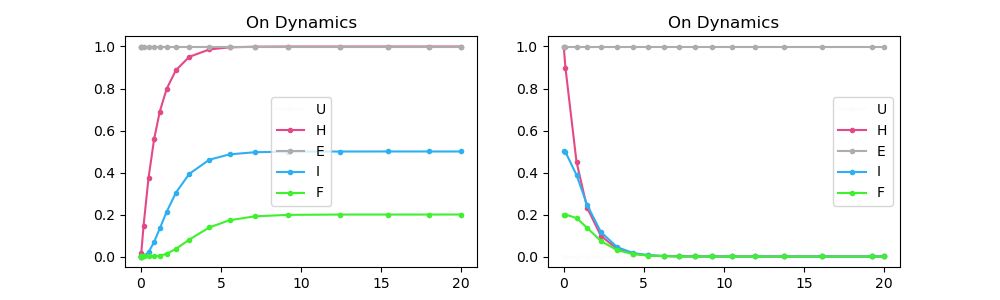

In [11]:
pn.Row(
    pn.Column(log_alpha_slider,
        log_beta_slider,
        log_gamma_slider,
        log_kappa_i_slider,
        nH_slider,
        nI_slider
        ),
    simulate_cascade,
    )

# Autoactivation

In [12]:
#             E
#             |    _ 
#             V   V | 
#   U ---> H ---> F-

* Species: $U, H, E, F$
* Parameters: 
    * Dilution: $\nu$
    * Production: $\eta, \rho$
    * Activation: $a, n_H, K_H, n_F, K_F$
\begin{align}
\\ \frac{dU}{dt} &= 0
\\ \frac{dH}{dt} &= \eta U - \nu H
\\ \frac{dE}{dt} &= \rho - \nu E
\\ \frac{dF}{dt} &= \frac{aE}{2} \left( \frac{H^{n_H}}{K_H^{n_H} + H^{n_H}} + \frac{F^{n_F}}{K_F^{n_F} + F^{n_F}} \right) - \nu F
\end{align}

_Non-dimensional_
* Parameters:
    * $\alpha = \frac{\eta}{\nu}$
    * $\beta = \frac{\rho}{K_H \nu}$
    * $\gamma = \frac{a}{\nu}$
    * $\kappa_F = \left(\frac{K_F}{K_H}\right)^{n_F}$
    * $n_H, n_F$
    
\begin{align}
\\ \frac{dU}{dt} &= 0
\\ \frac{dH}{dt} &= \alpha U - H
\\ \frac{dE}{dt} &= \beta - E
\\ \frac{dF}{dt} &= \frac{\gamma E}{2} \left( \frac{H^{n_H}}{1 + H^{n_H}} + \frac{F^{n_F}}{ \kappa_F + F^{n_F}} \right) - F
\end{align}

## Time derivatives

In [13]:
def dy_dt_autoactivate(t, y, prms):
    """
    Inputs:
    -------
    t: float
    y: array (4,)
        U, H, E, F
    prms: array (6,)
        alpha, beta, gamma, kappa_f, nH, nF
        
    Outputs:
    --------
    dy_dt: array (4,)
    """
    alpha, beta, gamma, kappa_f, nH, nF = prms
    U, H, E, F = y
    
    dU_dt = 0
    dH_dt = alpha * U - H
    dE_dt = beta - E
    dF_dt = (gamma*E) / 2 * ((H**nH / (1 + H**nH)) + (F**nF / (kappa_f + F**nF))) - F
    
    return np.array([dU_dt, dH_dt, dE_dt, dF_dt])
    
    

## Interactive plot

In [28]:
@pn.depends(
    log_alpha_slider.param.value,
    log_beta_slider.param.value,
    log_gamma_slider.param.value,
    log_kappa_f_slider.param.value,
    nH_slider.param.value,
    nF_slider.param.value,
)
def simulate_autoactivate(log_alpha, log_beta, log_gamma, log_kappa_f, nH, nF,
                        species_names = ['U','H','E','F']):
    
    alpha, beta, gamma, kappa_f = 10.**np.array([log_alpha, log_beta, log_gamma, log_kappa_f])

    prms = (alpha, beta, gamma, kappa_f, nH, nF)

    fig, axes = plt.subplots(1,2, figsize=(10,3))
    t_span = (0, 15)

    # Initial conditions
    rng = np.random.default_rng(10)

    U_0 = 0.5
    H_0 = 0
    E_0 = rng.poisson(lam=beta)
    F_0 = 0
    y0 = np.array([U_0, H_0, E_0, F_0])

    # On dynamics
    on_res = scipy.integrate.solve_ivp(lambda t, y: dy_dt_autoactivate(t, y, prms=prms), t_span, y0)
        
    for s, species in enumerate(species_names):
        axes[0].plot(on_res.t, on_res.y[s], '.-', 
                     color=color_dict[species],
                     label=species)
        
    axes[0].legend()
    axes[0].set_title('On Dynamics')

    # On steady-state
    U_ss = 0
    H_ss = on_res.y[1,-1]
    E_ss = on_res.y[2,-1]
    F_ss = on_res.y[3,-1]
    y_ss = np.array([U_ss, H_ss, E_ss, F_ss])
    
    # Predicted off steady-state values
    discriminant = (beta * gamma)**2 - 4*kappa_f
    pred_off_ss = ((beta * gamma + discriminant**(0.5)) / 2, (beta * gamma - discriminant**(0.5)) / 2)
    
    for ss in pred_off_ss:
        if discriminant < 0:
            axes[1].text(1, E_ss, 'complex_root')
        else:
            axes[1].plot(t_span, ss*np.ones_like(t_span), '-k')

    # Off dynamics
    off_res = scipy.integrate.solve_ivp(lambda t, y: dy_dt_autoactivate(t, y, prms=prms), t_span, y_ss)

    for s, species in enumerate(species_names):
        axes[1].plot(off_res.t, off_res.y[s], '.-', 
                     color=color_dict[species],
                     label=species)

    axes[1].legend()
    axes[1].set_title('Off Dynamics')
    
    plt.close(fig)
    
    return fig

/var/folders/px/trv02g9x5vz73qbwllrbnxtw0000gn/T/ipykernel_14770/2934739696.py:48: RuntimeWarning: invalid value encountered in double_scalars
  pred_off_ss = ((beta * gamma + discriminant**(0.5)) / 2, (beta * gamma - discriminant**(0.5)) / 2)


Row
    [0] Column
        [0] FloatSlider(end=4, name='$log alpha$', start=-4, value=-0.10000000000000009, width=300)
        [1] FloatSlider(end=4, name='$log beta$', start=-4, width=300)
        [2] FloatSlider(end=4, name='$log gamma$', start=-4, value=-0.20000000000000018, width=300)
        [3] FloatSlider(end=4, name='$log kappa_f$', start=-4, width=300)
        [4] FloatSlider(end=10, name='$n_H$', value=2, width=300)
        [5] FloatSlider(end=10, name='$n_F$', value=2, width=300)
    [1] ParamFunction(function)
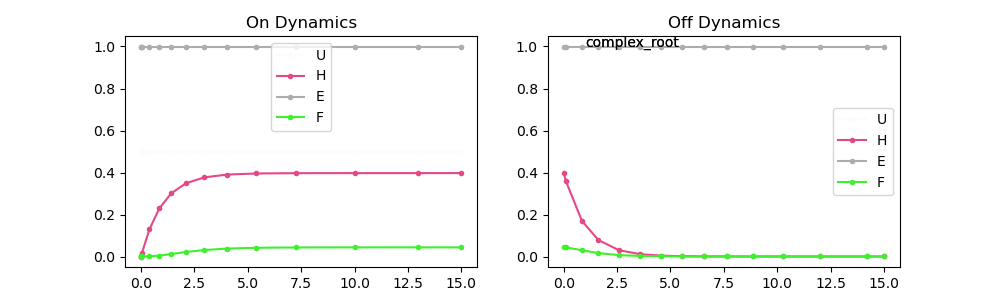

In [29]:
pn.Row(
    pn.Column(log_alpha_slider,
        log_beta_slider,
        log_gamma_slider,
        log_kappa_f_slider,
        nH_slider,
        nF_slider
        ),
    simulate_autoactivate,
    )

# Feedforward loop

In [16]:
#   Positive
#             E
#             |    
#             V    
#   U ---> H ---> I ---> F
#                |      ^
#                V      |
#.                   J

#   Negative
#             E
#             |    
#             V    
#   U ---> H ---> I ---> F
#                |      _
#                V      |
#.                   J

* Species: $U, H, E, I, J, F$
* Parameters: 
    * Dilution: $\nu$
    * Production: $\eta, \rho$
    * Activation: $a, n_H, K_H, n_I, K_I, n_J, K_J$
\begin{align}
\\ \frac{dU}{dt} &= 0
\\ \frac{dH}{dt} &= \eta U - \nu H
\\ \frac{dE}{dt} &= \rho - \nu E
\\ \frac{dI}{dt} &= aE \frac{H^{n_H}}{K_H^{n_H} + H^{n_H}} - \nu I
\\ \frac{dJ}{dt} &= aE \frac{I^{n_I}}{K_I^{n_I} + I^{n_I}} - \nu J
\\ \frac{dF}{dt} &= \frac{aE}{2} \left( \frac{I^{n_I}}{K_I^{n_I} + I^{n_I}} + \frac{J^{n_J}}{K_J^{n_J} + J^{n_J}} \right) - \nu F
\end{align}

_Non-dimensional_
* Parameters:
    * $\alpha = \frac{\eta}{\nu}$
    * $\beta = \frac{\rho}{K_H \nu}$
    * $\gamma = \frac{a}{\nu}$
    * $\kappa_I = \left(\frac{K_I}{K_H}\right)^{n_I}$
    * $\kappa_J = \left(\frac{K_J}{K_H}\right)^{n_J}$
    * $n_H, n_I, n_J$
    
\begin{align}
\\ \frac{dU}{dt} &= 0
\\ \frac{dH}{dt} &= \alpha U - H
\\ \frac{dE}{dt} &= \beta - E
\\ \frac{dI}{dt} &= \gamma E \frac{H^{n_H}}{1 + H^{n_H}} - I
\\ \frac{dJ}{dt} &= \gamma E \frac{I^{n_I}}{\kappa_I + I^{n_I}} - J
\\ \frac{dF}{dt} &= \frac{\gamma E}{2} \left( \frac{I^{n_I}}{\kappa_I + I^{n_I}} + \frac{J^{n_J}}{\kappa_J + J^{n_J}} \right) - F
\end{align}

For negative feedforward:
_New Way_
\begin{align}
\\ \frac{dF}{dt} &= \frac{\gamma E}{2} \left( \frac{I^{n_I}}{\kappa_I + I^{n_I}} + \frac{\kappa_J}{\kappa_J + J^{n_J}} \right) - F
\end{align}

_Old Way_
\begin{align}
\\ \frac{dF}{dt} &= \gamma E \left( \frac{I^{n_I}}{\kappa_I + I^{n_I}} \right) \left( \frac{\kappa_J}{\kappa_J + J^{n_J}} \right) - F
\end{align}

## Time derivative

In [17]:
def dy_dt_feedforward(t, y, prms, sign='positive'):
    """
    Inputs:
    -------
    t: float
    y: array (6,)
        U, H, E, I, J, F
    prms: array (8,)
        alpha, beta, gamma, kappa_i, kappa_j, nH, nI, nJ
        
    Outputs:
    --------
    dy_dt: array (6,)
    """
    alpha, beta, gamma, kappa_i, kappa_j, nH, nI, nJ = prms
    U, H, E, I, J, F = y
    
    dU_dt = 0
    dH_dt = alpha*U - H
    dE_dt = beta - E
    dI_dt = gamma * E * H**nH / (1 + H**nH) - I
    dJ_dt = gamma * E * I**nI / (kappa_i + I**nI) - J
    if sign=='positive':
        dF_dt = gamma * E / 2 * (I**nI / (kappa_i + I**nI) + J**nJ / (kappa_j + J**nJ)) - F
    elif sign=='negative':
        dF_dt = gamma * E / 2 * (I**nI / (kappa_i + I**nI) + kappa_j / (kappa_j + J**nJ)) - F
        # dF_dt = gamma * E * (I**nI / (kappa_i + I**nI) * kappa_j / (kappa_j + J**nJ)) - F
    else:
        print('Sign must be positive "positive" or "negative".')
    
    return np.array([dU_dt, dH_dt, dE_dt, dI_dt, dJ_dt, dF_dt])
    
    

## Interactive plot

In [18]:
@pn.depends(
    # sign_select.value,
    log_alpha_slider.param.value,
    log_beta_slider.param.value,
    log_gamma_slider.param.value,
    log_kappa_i_slider.param.value,
    log_kappa_j_slider.param.value,
    nH_slider.param.value,
    nI_slider.param.value,
    nJ_slider.param.value,
)
def simulate_feedforward(log_alpha, log_beta, log_gamma, log_kappa_i, log_kappa_j, nH, nI, nJ,
                        species_names = ['U','H','E','I','J','F']):
    
    sign='positive'

    alpha, beta, gamma, kappa_i, kappa_j = 10.**np.array([log_alpha, log_beta, log_gamma, log_kappa_i, log_kappa_j])

    prms = (alpha, beta, gamma, kappa_i, kappa_j, nH, nI, nJ)
    
    fig, axes = plt.subplots(1,2, figsize=(10,3))
    t_span = (0, 20)

    # Initial conditions
    rng = np.random.default_rng(10)

    U_0 = 1
    H_0 = 0
    E_0 = rng.poisson(lam=beta)
    I_0 = 0
    J_0 = 0
    F_0 = 0
    y0 = np.array([U_0, H_0, E_0, I_0, J_0, F_0])

    # On dynamics
    on_res = scipy.integrate.solve_ivp(lambda t, y: dy_dt_feedforward(t, y, prms=prms, sign=sign), t_span, y0)

    for s, species in enumerate(species_names):
        axes[0].plot(on_res.t, on_res.y[s], '.-', 
                     color=color_dict[species],
                     label=species)

    axes[0].legend()
    axes[0].set_title('On Dynamics')

    # steady-state
    U_ss = 0
    H_ss = on_res.y[1,-1]
    E_ss = on_res.y[2,-1]
    I_ss = on_res.y[3,-1]
    J_ss = on_res.y[4,-1]
    F_ss = on_res.y[5,-1]
    y_ss = np.array([U_ss, H_ss, E_ss, I_ss, J_ss, F_ss])

    # Off dynamics
    off_res = scipy.integrate.solve_ivp(lambda t, y: dy_dt_feedforward(t, y, prms=prms, sign=sign), t_span, y_ss)

    for s, species in enumerate(species_names):
        axes[1].plot(off_res.t, off_res.y[s], '.-', 
                     color=color_dict[species],
                     label=species)

    axes[1].legend()
    axes[1].set_title('On Dynamics')
    
    plt.close(fig)
    
    return fig

Row
    [0] Column
        [0] FloatSlider(end=4, name='$log alpha$', start=-4, width=300)
        [1] FloatSlider(end=4, name='$log beta$', start=-4, width=300)
        [2] FloatSlider(end=4, name='$log gamma$', start=-4, width=300)
        [3] FloatSlider(end=4, name='$log kappa_i$', start=-4, width=300)
        [4] FloatSlider(end=4, name='$log kappa_j$', start=-4, width=300)
        [5] FloatSlider(end=10, name='$n_H$', value=2, width=300)
        [6] FloatSlider(end=10, name='$n_I$', value=2, width=300)
        [7] FloatSlider(end=10, name='$n_J$', value=2, width=300)
    [1] ParamFunction(function)
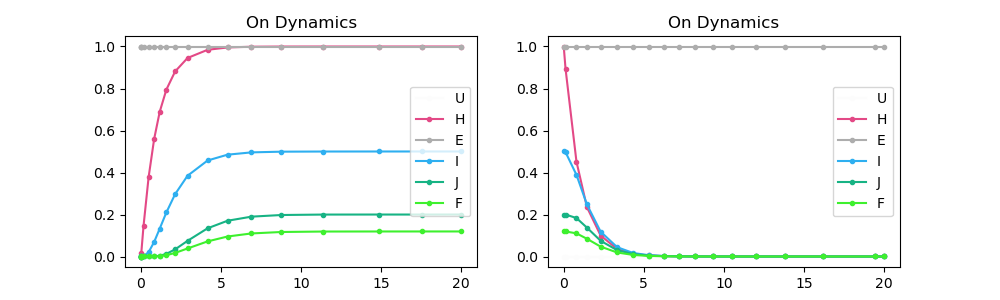

In [19]:
pn.Row(
    pn.Column(log_alpha_slider,
        log_beta_slider,
        log_gamma_slider,
        log_kappa_i_slider,
        log_kappa_j_slider,
        nH_slider,
        nI_slider,
        nJ_slider
         ),
    simulate_feedforward,
    )

# Feedback loop

In [20]:
#   Positive
#             E
#             |    
#             V    
#   U ---> H ---> I ---> F
#                ^      |
#                |      V
#.                   J

#   Negative
#             E
#             |    
#             V    
#   U ---> H ---> I ---> F
#                ^      |
#                |      _
#.                   J

* Species: $U, H, E, I, J, F$
* Parameters: 
    * Dilution: $\nu$
    * Production: $\eta, \rho$
    * Activation: $a, n_H, K_H, n_I, K_I, n_J, K_J$
\begin{align}
\\ \frac{dU}{dt} &= 0
\\ \frac{dH}{dt} &= \eta U - \nu H
\\ \frac{dE}{dt} &= \rho - \nu E
\\ \frac{dI}{dt} &= \frac{aE}{2} \left(\frac{H^{n_H}}{K_H^{n_H} + H^{n_H}} + \frac{J^{n_J}}{K_J^{n_J} + J^{n_J}}\right) - \nu I
\\ \frac{dJ}{dt} &= aE \frac{F^{n_F}}{K_F^{n_F} + F^{n_F}} - \nu J
\\ \frac{dF}{dt} &= aE \frac{I^{n_I}}{K_I^{n_I} + I^{n_I}}  - \nu F
\end{align}

_Non-dimensional_
* Parameters:
    * $\alpha = \frac{\eta}{\nu}$
    * $\beta = \frac{\rho}{K_H \nu}$
    * $\gamma = \frac{a}{\nu}$
    * $\kappa_I = \left(\frac{K_I}{K_H}\right)^{n_I}$
    * $\kappa_J = \left(\frac{K_J}{K_H}\right)^{n_J}$
    * $\kappa_F = \left(\frac{K_F}{K_H}\right)^{n_F}$
    * $n_H, n_I, n_J, n_F$
    
\begin{align}
\\ \frac{dU}{dt} &= 0
\\ \frac{dH}{dt} &= \alpha U - H
\\ \frac{dE}{dt} &= \beta - E
\\ \frac{dI}{dt} &= \frac{\gamma E}{2} \left( \frac{H^{n_H}}{1 + H^{n_H}} + \frac{J^{n_J}}{\kappa_J + J^{n_J}} \right) - I
\\ \frac{dJ}{dt} &= \gamma E \frac{F^{n_F}}{\kappa_F + F^{n_F}} - J
\\ \frac{dF}{dt} &= \gamma E \frac{I^{n_I}}{\kappa_I + I^{n_I}}  - F
\end{align}

For negative feedforward:
\begin{align}
\\ \frac{dJ}{dt} &= \gamma E \frac{\kappa_F}{\kappa_F + F^{n_F}} - J
\end{align}

## Time derivative

In [21]:
def dy_dt_feedback(t, y, prms, sign='positive'):
    """
    Inputs:
    -------
    t: float
    y: array (6,)
        U, H, E, I, J, F
    prms: array (8,)
        alpha, beta, gamma, kappa_i, kappa_j, kappa_f, nH, nI, nJ, nF
        
    Outputs:
    --------
    dy_dt: array (6,)
    """
    alpha, beta, gamma, kappa_i, kappa_j, kappa_f, nH, nI, nJ, nF = prms
    U, H, E, I, J, F = y
    
    dU_dt = 0
    dH_dt = alpha*U - H
    dE_dt = beta - E
    dI_dt = gamma * E / 2 * (H**nH / (1 + H**nH) + J**nJ / (kappa_j + J**nJ)) - I

    dF_dt = gamma * E * I**nI / (kappa_i + I**nI) - F

    if sign=='positive':
        dJ_dt = gamma * E * F**nF / (kappa_f + F**nF) - J
    elif sign=='negative':
        dJ_dt = gamma * E * kappa_f / (kappa_f + F**nF) - J
    else:
        print('Sign must be positive "positive" or "negative".')
    
    return np.array([dU_dt, dH_dt, dE_dt, dI_dt, dJ_dt, dF_dt])
    
    

## Interactive plot

In [22]:
@pn.depends(
    # sign_select.value,
    log_alpha_slider.param.value,
    log_beta_slider.param.value,
    log_gamma_slider.param.value,
    log_kappa_i_slider.param.value,
    log_kappa_j_slider.param.value,
    log_kappa_f_slider.param.value,
    nH_slider.param.value,
    nI_slider.param.value,
    nJ_slider.param.value,
    nF_slider.param.value,
)
def simulate_feedback(log_alpha, log_beta, log_gamma, log_kappa_i, log_kappa_j, log_kappa_f, nH, nI, nJ, nF,
                        species_names = ['U','H','E','I','J','F']):
    
    sign='negative'

    alpha, beta, gamma, kappa_i, kappa_j, kappa_f = 10.**np.array([log_alpha, log_beta, log_gamma, log_kappa_i, log_kappa_j, log_kappa_f])

    prms = (alpha, beta, gamma, kappa_i, kappa_j, kappa_f, nH, nI, nJ, nF)
    
    fig, axes = plt.subplots(1,2, figsize=(10,3))
    t_span = (0, 20)

    # Initial conditions
    rng = np.random.default_rng(10)

    U_0 = 1
    H_0 = 0
    E_0 = rng.poisson(lam=beta)
    I_0 = 0
    J_0 = 0
    F_0 = 0
    y0 = np.array([U_0, H_0, E_0, I_0, J_0, F_0])

    # On dynamics
    on_res = scipy.integrate.solve_ivp(lambda t, y: dy_dt_feedback(t, y, prms=prms, sign=sign), t_span, y0)

    for s, species in enumerate(species_names):
        axes[0].plot(on_res.t, on_res.y[s], '.-', 
                     color=color_dict[species],
                     label=species)

    axes[0].legend()
    axes[0].set_title('On Dynamics')

    # steady-state
    U_ss = 0
    H_ss = on_res.y[1,-1]
    E_ss = on_res.y[2,-1]
    I_ss = on_res.y[3,-1]
    J_ss = on_res.y[4,-1]
    F_ss = on_res.y[5,-1]
    y_ss = np.array([U_ss, H_ss, E_ss, I_ss, J_ss, F_ss])

    # Off dynamics
    off_res = scipy.integrate.solve_ivp(lambda t, y: dy_dt_feedback(t, y, prms=prms, sign=sign), t_span, y_ss)

    for s, species in enumerate(species_names):
        axes[1].plot(off_res.t, off_res.y[s], '.-', 
                     color=color_dict[species],
                     label=species)

    axes[1].legend()
    axes[1].set_title('Off Dynamics')
    
    plt.close(fig)
    
    return fig

Row
    [0] Column
        [0] FloatSlider(end=4, name='$log alpha$', start=-4, width=300)
        [1] FloatSlider(end=4, name='$log beta$', start=-4, width=300)
        [2] FloatSlider(end=4, name='$log gamma$', start=-4, width=300)
        [3] FloatSlider(end=4, name='$log kappa_i$', start=-4, width=300)
        [4] FloatSlider(end=4, name='$log kappa_j$', start=-4, width=300)
        [5] FloatSlider(end=4, name='$log kappa_f$', start=-4, width=300)
        [6] FloatSlider(end=10, name='$n_H$', value=2, width=300)
        [7] FloatSlider(end=10, name='$n_I$', value=2, width=300)
        [8] FloatSlider(end=10, name='$n_J$', value=2, width=300)
        [9] FloatSlider(end=10, name='$n_F$', value=2, width=300)
    [1] ParamFunction(function)
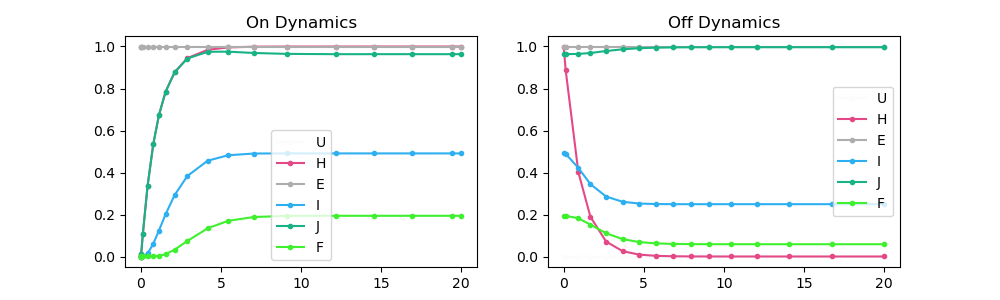

In [23]:
pn.Row(
    pn.Column(log_alpha_slider,
        log_beta_slider,
        log_gamma_slider,
        log_kappa_i_slider,
        log_kappa_j_slider,
        log_kappa_f_slider,
        nH_slider,
        nI_slider,
        nJ_slider,
        nF_slider,
         ),
    simulate_feedback,
    )